<a href="https://colab.research.google.com/github/CorgiFan/MRI_Tumor_Detection/blob/main/Torch_Tumor_Detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import kagglehub

# Downloads the brain tumor MRI dataset from Kaggle to a local path
path = kagglehub.dataset_download("masoudnickparvar/brain-tumor-mri-dataset")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'brain-tumor-mri-dataset' dataset.
Path to dataset files: /kaggle/input/brain-tumor-mri-dataset


In [2]:
import torch
import torch.nn as nn
import torch.optim as optim

from torch.utils.data import DataLoader, TensorDataset

from torchvision import datasets
from torchvision import transforms
from torchvision import models

import matplotlib.pyplot as plt
import numpy as np

In [3]:
# Loading in the data
train_dir = path + "/Training"
test_dir = path + "/Testing"

# Normalization to help CNN converge faster
normalize = transforms.Normalize(mean=[0.485, 0.456, 0.406],
                                  std=[0.229, 0.224, 0.225])

# Random augmentation to prevent overfitting
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    normalize
])

# No random augmentation so the real image is evaluated
test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    normalize])

# Label images off subfolder name
train_dataset = datasets.ImageFolder(
    root=train_dir,
    transform=train_transform
)

test_dataset = datasets.ImageFolder(
    root=test_dir,
    transform=test_transform
)

# DataLoader handles batching and shuffling data
train_loader = DataLoader(
    train_dataset,
    batch_size = 32,
    shuffle = True
)

test_loader = DataLoader(
    test_dataset,
    batch_size = 32,
    shuffle = False
)

In [4]:
class TumorModel(nn.Module):
  def __init__(self):
    super().__init__()

    # 3 convolution blocks, each doubles channel depth and halves spatial size
    self.features = nn.Sequential(
      nn.Conv2d(3, 32, kernel_size=3, stride=1, padding=1),
      nn.ReLU(),
      nn.MaxPool2d(2),

      nn.Conv2d(32, 64, kernel_size=3, stride=1, padding=1),
      nn.ReLU(),
      nn.MaxPool2d(2),

      nn.Conv2d(64, 128, kernel_size=3, stride=1, padding=1),
      nn.ReLU(),
      nn.MaxPool2d(2),
    )

    # Flattens feature maps down to 4 class scores
    self.classifier = nn.Sequential(
      nn.Flatten(),
      nn.Linear(128 * 28 * 28, 512),
      nn.ReLU(),
      nn.Dropout(0.5),
      nn.Linear(512, 4)
    )
  def forward(self, x):
    x = self.features(x)
    x = self.classifier(x)
    return x

In [5]:
# Uses GPU if available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

model = TumorModel().to(device)

# CrossEntropyLoss
criterion = nn.CrossEntropyLoss()

# Adam optimizer
optimizer = torch.optim.Adam(
    model.parameters(),
    lr=1e-3
)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='max', factor=0.5, patience=3
)

Using device: cuda


In [6]:
print(torch.cuda.is_available())

True


In [7]:
epochs = 30
best_accuracy = 0.0
patience = 7        # Early stopping
epochs_no_improve = 0

train_losses = []       # Track loss per epoch
val_accuracies = []     # Track validation accuracy per epoch

for epoch in range(epochs):

    #------------------------------------------Training Phase--------------------------------------------------
    model.train()
    running_loss = 0.0

    for X_batch, y_batch in train_loader:
        # Move batch to same device as model (GPU in this case)
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)

        optimizer.zero_grad()                        # Clear gradients
        outputs = model(X_batch)                     # Forward pass
        loss = criterion(outputs, y_batch)           # Calculate loss
        loss.backward()                              # Backward pass
        optimizer.step()                             # Update weights

        running_loss += loss.item() * X_batch.size(0)

    epoch_loss = running_loss / len(train_dataset)
    train_losses.append(epoch_loss)

    #-------------------------------------------Validation Phase-------------------------------------------
    model.eval()
    correct = 0
    total = 0

    with torch.no_grad():         # Disable gradient tracking to save resources
        for X_batch, y_batch in test_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)

            outputs = model(X_batch)
            predictions = torch.argmax(outputs, dim=1)

            correct += (predictions == y_batch).sum().item()
            total += y_batch.size(0)

    accuracy = correct / total
    val_accuracies.append(accuracy)

    scheduler.step(accuracy)    # Lets scheduler know accuracy

    print(f"Epoch {epoch+1}/{epochs}: Train Loss = {epoch_loss:.4f}, Val Accuracy = {accuracy:.4f}")

    #-----------------------------------------Checkpoint and Early Stopping-----------------------------------
    if accuracy > best_accuracy:
        best_accuracy = accuracy
        epochs_no_improve = 0
        torch.save(model.state_dict(), "best_model.pth")
    else:
        epochs_no_improve += 1
        if epochs_no_improve >= patience:
            print(f"Early stopping at epoch {epoch+1} (no improvement for {patience} epochs)")
            break

print(f"\nBest validation accuracy: {best_accuracy:.4f}")

Epoch 1/30: Train Loss = 0.8869, Val Accuracy = 0.7300
Epoch 2/30: Train Loss = 0.4617, Val Accuracy = 0.7900
Epoch 3/30: Train Loss = 0.3554, Val Accuracy = 0.8369
Epoch 4/30: Train Loss = 0.2709, Val Accuracy = 0.8381
Epoch 5/30: Train Loss = 0.2206, Val Accuracy = 0.8425
Epoch 6/30: Train Loss = 0.2005, Val Accuracy = 0.9106
Epoch 7/30: Train Loss = 0.1475, Val Accuracy = 0.8869
Epoch 8/30: Train Loss = 0.1278, Val Accuracy = 0.9131
Epoch 9/30: Train Loss = 0.1077, Val Accuracy = 0.9175
Epoch 10/30: Train Loss = 0.1173, Val Accuracy = 0.9200
Epoch 11/30: Train Loss = 0.0991, Val Accuracy = 0.9213
Epoch 12/30: Train Loss = 0.0803, Val Accuracy = 0.9269
Epoch 13/30: Train Loss = 0.0617, Val Accuracy = 0.9194
Epoch 14/30: Train Loss = 0.0752, Val Accuracy = 0.9269
Epoch 15/30: Train Loss = 0.0668, Val Accuracy = 0.9263
Epoch 16/30: Train Loss = 0.0504, Val Accuracy = 0.9263
Epoch 17/30: Train Loss = 0.0272, Val Accuracy = 0.9331
Epoch 18/30: Train Loss = 0.0300, Val Accuracy = 0.9356
E

['glioma', 'meningioma', 'notumor', 'pituitary']


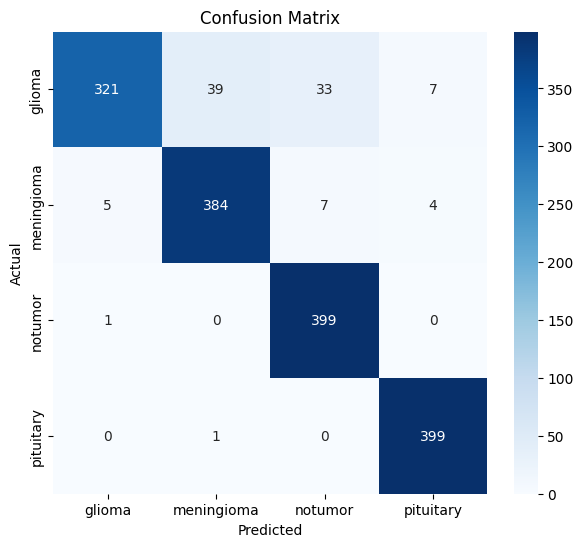

              precision    recall  f1-score   support

      glioma       0.98      0.80      0.88       400
  meningioma       0.91      0.96      0.93       400
     notumor       0.91      1.00      0.95       400
   pituitary       0.97      1.00      0.99       400

    accuracy                           0.94      1600
   macro avg       0.94      0.94      0.94      1600
weighted avg       0.94      0.94      0.94      1600



In [9]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

# Reload best checkpoints (highest accuracy)
model.load_state_dict(torch.load("best_model.pth"))
model.to(device)
model.eval()

all_preds = []
all_labels = []

with torch.no_grad():
    for X_batch, y_batch in test_loader:
        X_batch = X_batch.to(device)
        outputs = model(X_batch)
        predictions = torch.argmax(outputs, dim=1)

        # Move predictions back to CPU and convert to numpy, sklearn requires CPU arrays
        all_preds.extend(predictions.cpu().numpy())
        all_labels.extend(y_batch.numpy())

class_names = test_dataset.classes
print(class_names)

cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(7, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.savefig("confusion_matrix.png", dpi=150, bbox_inches='tight')
plt.show()

# Per-class precision, recall, and F1
print(classification_report(all_labels, all_preds, target_names=class_names))